In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [2]:
# Load data
jwst_file = "/scratch/wyz5rge/synthetic-hr/notebooks/2025/08-11_morten-chi-squared-cross-reference/winstonlist.dat"
hst_file  = "/scratch/wyz5rge/synthetic-hr/notebooks/2025/08-11_morten-chi-squared-cross-reference/HST_phot.dat"

# JWST x,y in cols 0,1
jwst = np.loadtxt(jwst_file, usecols=(0,1))
# HST x,y in cols 0,1
hst = np.loadtxt(hst_file, usecols=(0,1))

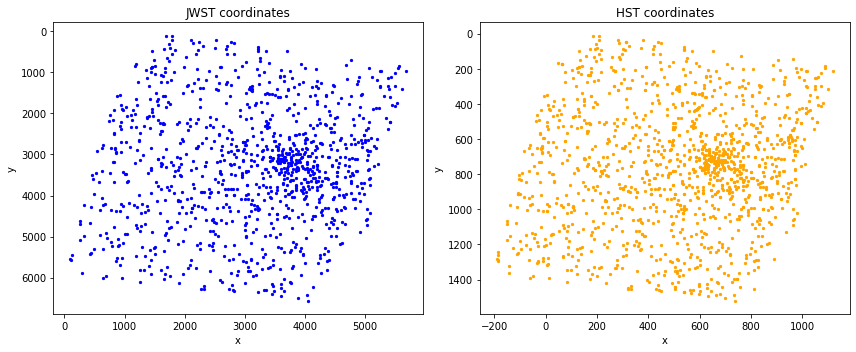

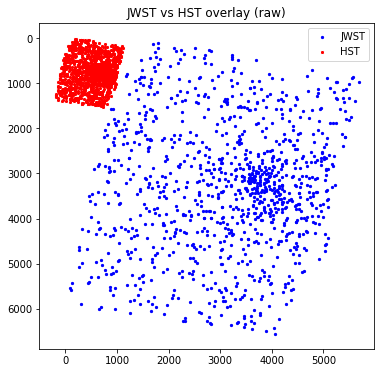

In [3]:
# Plot separately and overlay (before alignment)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(jwst[:,0], jwst[:,1], s=5, c="blue")
plt.gca().invert_yaxis()
plt.title("JWST coordinates")
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(1,2,2)
plt.scatter(hst[:,0], hst[:,1], s=5, c="orange")
plt.gca().invert_yaxis()
plt.title("HST coordinates")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()

# Overlay
plt.figure(figsize=(6,6))
plt.scatter(jwst[:,0], jwst[:,1], s=5, c="blue", label="JWST")
plt.scatter(hst[:,0], hst[:,1], s=5, c="red", marker="x", label="HST")
plt.gca().invert_yaxis()
plt.legend()
plt.title("JWST vs HST overlay (raw)")
plt.show()

In [4]:
# Estimate pre-scaling factor from cloud extents
jwst_range = np.max(jwst, axis=0) - np.min(jwst, axis=0)
hst_range  = np.max(hst, axis=0) - np.min(hst, axis=0)

scale_factor = np.mean(jwst_range / hst_range)
print("Estimated scale factor:", scale_factor)

hst_prescaled = hst * scale_factor

Estimated scale factor: 4.275003198449666


In [5]:
# Define rigid ICP (no scaling)
def icp_rigid_no_scale(A, B, max_iterations=50, tolerance=1e-6):
    src = np.copy(A)
    prev_error = float("inf")

    for i in range(max_iterations):
        nbrs = NearestNeighbors(n_neighbors=1).fit(B)
        distances, indices = nbrs.kneighbors(src)
        closest_points = B[indices[:,0]]

        centroid_src = np.mean(src, axis=0)
        centroid_dst = np.mean(closest_points, axis=0)

        src_centered = src - centroid_src
        dst_centered = closest_points - centroid_dst

        H = src_centered.T @ dst_centered
        U, _, Vt = np.linalg.svd(H)
        R = Vt.T @ U.T
        if np.linalg.det(R) < 0:
            Vt[-1,:] *= -1
            R = Vt.T @ U.T

        t = centroid_dst - R @ centroid_src

        src = (R @ src.T).T + t

        mean_error = np.mean(distances)
        if abs(prev_error - mean_error) < tolerance:
            break
        prev_error = mean_error

    return src, R, t, mean_error

In [6]:
# Run ICP
hst_aligned, R, t, err = icp_rigid_no_scale(hst_prescaled, jwst)

print("Rotation matrix:\n", R)
print("Translation:", t)
print("Final mean NN error:", err)

Rotation matrix:
 [[ 9.99999986e-01  1.66947371e-04]
 [-1.66947371e-04  9.99999986e-01]]
Translation: [0.80585161 0.22714214]
Final mean NN error: 19.32843743726078


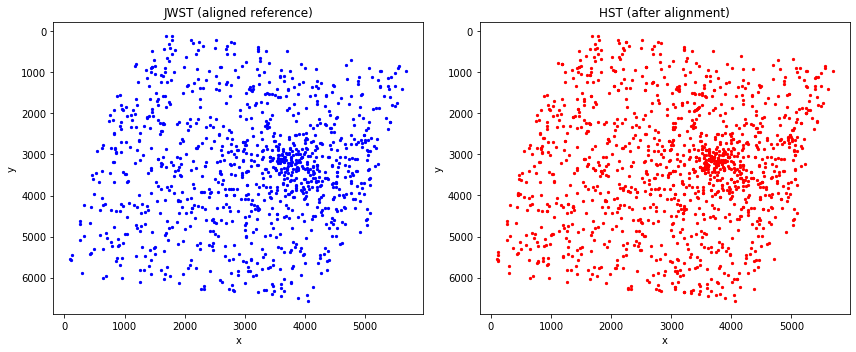

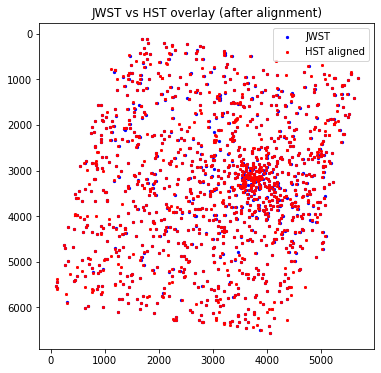

In [8]:
# Plot JWST, aligned HST, and overlay
plt.figure(figsize=(12,5))

# JWST only
plt.subplot(1,2,1)
plt.scatter(jwst[:,0], jwst[:,1], s=5, c="blue")
plt.gca().invert_yaxis()
plt.title("JWST (aligned reference)")
plt.xlabel("x")
plt.ylabel("y")

# HST aligned only
plt.subplot(1,2,2)
plt.scatter(hst_aligned[:,0], hst_aligned[:,1], s=5, c="red")
plt.gca().invert_yaxis()
plt.title("HST (after alignment)")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()

# Overlay
plt.figure(figsize=(6,6))
plt.scatter(jwst[:,0], jwst[:,1], s=5, c="blue", label="JWST")
plt.scatter(hst_aligned[:,0], hst_aligned[:,1], s=5, c="red", marker="x", label="HST aligned")
plt.gca().invert_yaxis()
plt.legend()
plt.title("JWST vs HST overlay (after alignment)")
plt.show()